<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 142 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Bayesian Inference &middot; Challenge Solutions</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Worked solutions to the five practice challenges: prior sensitivity, credible vs confidence intervals, grid vs conjugate, P(B beats A) by simulation, and a posterior predictive check.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR = "#a21caf", "#2563eb", "#16a34a"   # fuchsia (Bayes), blue (data), green (posterior)
# shared teaching example: a landing-page conversion rate
a0, b0 = 2, 2        # prior Beta(2,2): weak, leans to the middle
conv, n = 8, 40      # data: 8 conversions in 40 visitors
aP, bP = a0+conv, b0+(n-conv)   # conjugate posterior Beta(10,34)
grid = np.linspace(0, 1, 500)
print("Bayesian toolkit ready | numpy", np.__version__)
# load the A/B dataset for challenges 4-5
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "bayesian-inference-in-practice--email-ab-test.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
g = df.groupby("variant")["converted"]
cA, nA = int(g.sum()["A"]), int(g.size()["A"])
cB, nB = int(g.sum()["B"]), int(g.size()["B"])

Bayesian toolkit ready | numpy 2.4.4


## Challenge 1 &middot; Change the prior
A flat `Beta(1,1)` sits at the MLE; a strong `Beta(20,20)` pulls hard toward 0.5. With only 8 of 40, the prior visibly moves the answer.

In [2]:
for (pa, pb) in [(1, 1), (2, 2), (20, 20)]:
    d = stats.beta(pa+conv, pb+n-conv)
    print(f"prior Beta({pa:2d},{pb:2d})  ->  posterior mean {d.mean():.3f}   (MLE is {conv/n:.3f})")

prior Beta( 1, 1)  ->  posterior mean 0.214   (MLE is 0.200)
prior Beta( 2, 2)  ->  posterior mean 0.227   (MLE is 0.200)
prior Beta(20,20)  ->  posterior mean 0.350   (MLE is 0.200)


## Challenge 2 &middot; Credible vs confidence
The 95% credible interval is a direct probability statement about theta; the Wald confidence interval approximates it from the MLE. With small n they differ, the credible interval respects the [0,1] boundary.

In [3]:
cred = stats.beta(aP, bP).ppf([0.025, 0.975])
phat = conv/n; se = np.sqrt(phat*(1-phat)/n)
wald = np.array([phat - 1.96*se, phat + 1.96*se])
print(f"95% credible interval : [{cred[0]:.3f}, {cred[1]:.3f}]   width {cred[1]-cred[0]:.3f}")
print(f"95% Wald CI           : [{wald[0]:.3f}, {wald[1]:.3f}]   width {wald[1]-wald[0]:.3f}")

95% credible interval : [0.118, 0.360]   width 0.243
95% Wald CI           : [0.076, 0.324]   width 0.248


## Challenge 3 &middot; Grid vs conjugate
How fine a grid do you need? Even a coarse grid gets the mean right; the curve smooths out as points increase.

In [4]:
exact = stats.beta(aP, bP).mean()
for m in [20, 100, 1000]:
    gg = np.linspace(0, 1, m)
    pg = stats.beta(a0, b0).pdf(gg) * stats.binom.pmf(conv, n, gg)
    pg /= np.trapezoid(pg, gg)
    print(f"{m:5d}-point grid  ->  mean {np.trapezoid(gg*pg, gg):.4f}   (exact {exact:.4f})")

   20-point grid  ->  mean 0.2273   (exact 0.2273)
  100-point grid  ->  mean 0.2273   (exact 0.2273)
 1000-point grid  ->  mean 0.2273   (exact 0.2273)


## Challenge 4 &middot; P(B > A) by simulation
Draw from each variant's posterior and compare. 100k draws reproduce the notebook's 99.6%.

In [5]:
postA, postB = stats.beta(1+cA, 1+nA-cA), stats.beta(1+cB, 1+nB-cB)
rng = np.random.default_rng(4)
sA, sB = postA.rvs(100000, random_state=rng), postB.rvs(100000, random_state=rng)
print(f"A: {cA}/{nA} = {cA/nA:.3f}   B: {cB}/{nB} = {cB/nB:.3f}")
print(f"P(B > A)      = {(sB > sA).mean():.4f}")
print(f"expected lift = {(sB-sA).mean()*100:.2f} pp")

A: 120/1000 = 0.120   B: 162/1000 = 0.162
P(B > A)      = 0.9965
expected lift = 4.18 pp


## Challenge 5 &middot; Posterior predictive check
Simulate replicated B campaigns and confirm the observed count sits comfortably inside, a model consistent with reality.

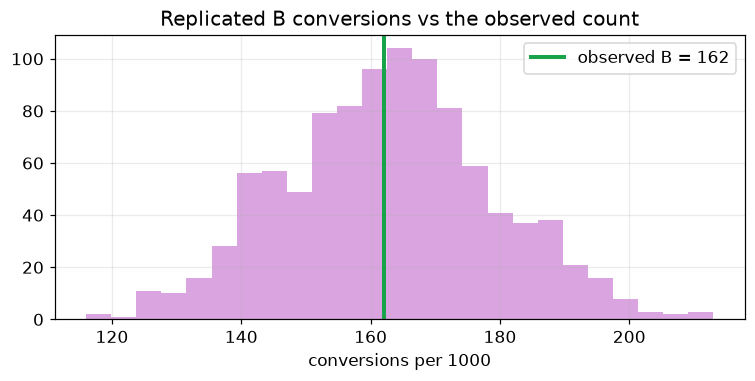

observed 162 is at the 46th percentile of the predictive distribution -> consistent


In [6]:
rng = np.random.default_rng(5)
rep = rng.binomial(nB, postB.rvs(1000, random_state=rng))
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(rep, bins=25, color=FU, alpha=0.4)
ax.axvline(cB, color=GR, lw=2.6, label=f"observed B = {cB}")
ax.set_title("Replicated B conversions vs the observed count"); ax.set_xlabel("conversions per 1000"); ax.legend()
plt.tight_layout(); plt.show()
print(f"observed {cB} is at the {(rep < cB).mean()*100:.0f}th percentile of the predictive distribution -> consistent")